# Demo to use the Stretcher object

## Table of content
0. [Modules and parameters.](#utils)  

1. [Case 1: Find the best stretching between a reference and another signal.](#case1)  
    1.1. [Step 1: Generate the reference and stretched signals.](#case1step1)  
    1.2. [Step 2: Pre-compute the stretched versions of the reference.](#case1step2)  
    1.3. [Step 3: Correlation of the observed signal with the reference.](#case1step3)  
    
2. [Case 2 : Find the stretching history in a b-scan using a single reference.](#case2)  
    2.1. [Step 1: Generate a b-scan with varying stretching as a function of time.](#case2step1)  
    2.2. [Step 2: Pre-compute the stretched versions of the reference.](#case2step2)  
    2.3. [Step 3: Correlate all signals of the bscan with the reference.](#case2step3)  
    
3. [Case 3 : Find the stretching history in a b-scan without any reference. [experimental]](#case3)  

4. [Case 4 : Iterative approach : Inverse-stretching](#case4)  

## Modules and parameters<a id="utils"></a>
### Modules<a id="modules"></a>

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from coodddaaaa.stretching import Stretcher 
from coodddaaaa.utils import Timer, polyspace
from coodddaaaa.butter import BandpassFilter
from coodddaaaa.utils import TukeyWindow

### Parameters<a id="parameters"></a>

In [2]:
# ============ SAMPLING 
t0 = -1e-5   # start time in sec
dt = 1e-6  # sampling interval, sec
nt = 512   # number of samples in time
time_array = t0 + np.arange(nt) * dt  # seconds  (NEVER use np.linspace for time vectors)

# ============ TIME WINDOW 
tmin = 1e-4   # begin of time window in sec
tmax = 4e-4   # end of time window in sec
taper_start = tmin-0.1*(tmax-tmin)  # start of the Tukey taper window
taper_end = tmax+0.1*(tmax-tmin)  # end of the Tukey taper window

# ============ FREQUENCY
fnyquist = 0.5 / dt    # Hz
fmin = 0.1 * fnyquist   # lower freq Hz
fmax = 0.5 * fnyquist   # upper freq Hz

# ============ STRETCHING (epsilon)
eps_true = 0.00123456789  # the imposed stretching coeff to be recovered

# Stretching search grid 
eps_search_min = -0.01  # min epsilon value (= -1% stretching)
eps_search_max = +0.01  # max epsilon value (= +1% stretching)
n_eps = 100  # number of epsilon values to test
eps_pw = 1.2  # controls the distribution of epsiolon values in the grid, 1 means linear spacing of the eps grid, > 1 means polynomial distribution of the grid

noise_level = 0.5  # level of noise added to the signal

interp_kind = "fourier"  # or 'linear', 'cubic'


In [3]:
# create the time taper
win = TukeyWindow(taper_start, tmin, tmax, taper_end)
taper: np.ndarray = win(time_array)

# and the callable bandpass filter
bandpass: callable = BandpassFilter(freqmin=fmin, freqmax=fmax, order=4, sampling_rate=1./dt)

## Case 1 : Find the best stretching between a reference and another signal<a id=case1></a>

### Step1 : Generate the reference and stretched signals<a id="case1step1"></a>

In [4]:
# Build the reference band-pass / tapered coda
y_reference = np.random.randn(nt)   # white Gaussian noise
y_reference = bandpass(y_reference, zerophase=True)   # bandpass
y_reference *= taper  # apply the Tukey taper


In [5]:
# Build the observed signal, a stretched version of it + noise

# stretcher0 is used to generate a stretched signal (norm=False), 
# do not use it for stretching-based correlation below
stretcher0 = Stretcher(t0=t0, nt=nt, dt=dt, eps=np.array([eps_true]), norm=False)  

# get the signal stretched by eps_true, 
y_observed = stretcher0.stretch(y_reference)

# there is only one trace here (i.e. one row in y_observed), 
# because stretcher0.eps has only one item 
y_observed = y_observed[0, :]

# add noise in the bandwidth only
y_observed += bandpass(np.random.randn(nt) * noise_level) * taper  

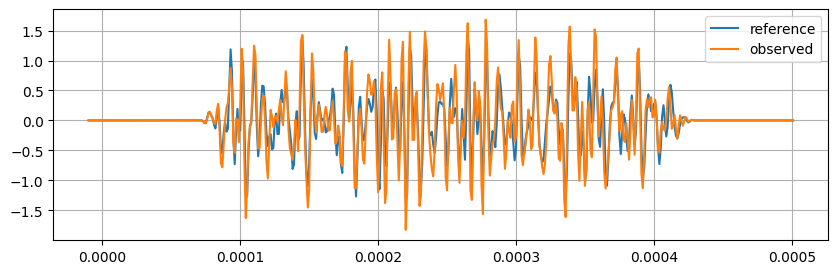

In [6]:
# Display
plt.figure(figsize=(10, 3))
plt.plot(time_array, y_reference, label="reference")
plt.plot(time_array, y_observed, label="observed");
plt.gca().legend();
plt.gca().grid(True)

### Step2 : Pre-compute the stretched versions of the reference<a id="case1step2"></a>

In [7]:
# Build the stretching basis of the reference signal

# epsilon search grid
# polyspace let you increase the grid resolution near eps=0, pwr=1 means linear scale
eps_search = polyspace(
    xmin=eps_search_min, 
    xmax=eps_search_max, 
    nx=n_eps, 
    pwr=eps_pw)

# Build the stretcher object for correlation this time (norm=True)
# (do not use stretcher0 which is not normalized)
# Most costly operations are performed here, once for all
with Timer('Build the stretcher object'):
    stretcher = Stretcher(
        t0=t0, nt=nt, dt=dt,
        eps=eps_search, 
        norm=True, 
        interp_kind=interp_kind)  

with Timer('Compute the stretched reference basis'):
    y_reference_stretched = stretcher.stretch(y_reference)


Timer[Build the stretcher object]: 599.53 ms
Timer[Compute the stretched reference basis]: 8.54 ms


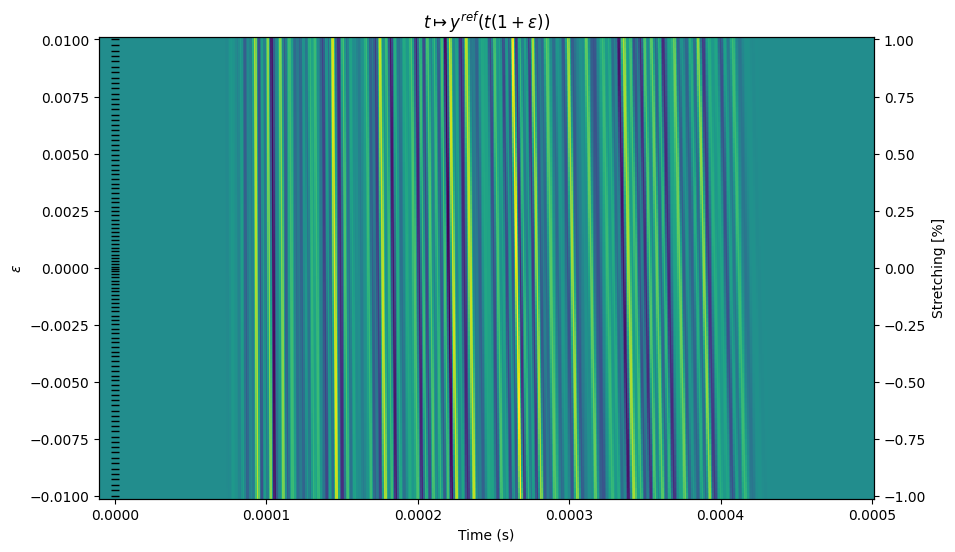

In [8]:
# Display
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, xlabel='Time (s)', ylabel='$ \epsilon $')

ax.pcolormesh(
    stretcher.t, 
    stretcher.eps, 
    y_reference_stretched, 
    shading="auto");

# show the epsilon grid as ticks on yaxis
ax.plot(eps_search * 0, eps_search, "k_"); 
ax.set_title(r'$t \mapsto y^{ref}(t (1 + \epsilon)) $')
bx = ax.twinx()
bx.set_ylim(np.asarray(ax.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');

### Step 3: Correlation of the observed signal with the reference<a id="case1step3"></a>

In [9]:
# Correlate observed with reference
with Timer('Normalized correlation'):
    c = stretcher.corr(y_observed, y_reference_stretched)  # correlation function, 1d, shape (neps, )

with Timer('Find the max of correlation with subsamp precision'):
    eps_max, c_max = stretcher.corrmax(c)  # 2 floats
    
with Timer('Compute Uncertainty'):
    eps_unc = stretcher.stretching_uncertainty(
        c_max, fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax)  # float
    

Timer[Normalized correlation]: 0.27 ms
Timer[Find the max of correlation with subsamp precision]: 0.12 ms
Timer[Compute Uncertainty]: 0.03 ms


### Results

In [10]:
print(f"expected stretching: {eps_true=}")
print(f"obtained stretching: {eps_max=}")
print(f"estimated stretching uncertainty: {eps_unc=}")
print(f"normalized correlation coefficient: {c_max=}")

expected stretching: eps_true=0.00123456789
obtained stretching: eps_max=0.00139463230689957
estimated stretching uncertainty: eps_unc=0.0001274350616099737
normalized correlation coefficient: c_max=0.898521654975452


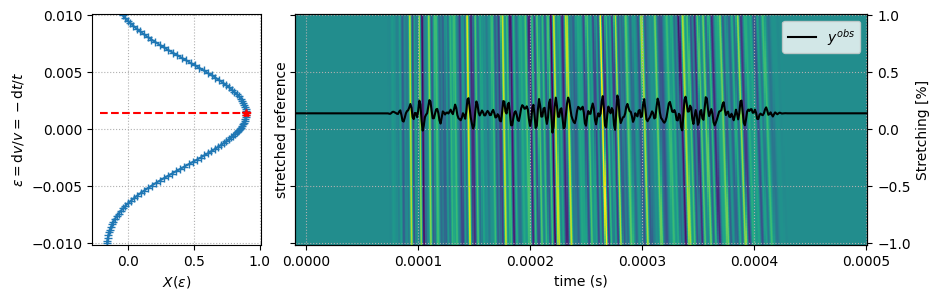

In [11]:
# Display
fig = plt.figure(figsize=(10, 3))
gs = fig.add_gridspec(1, 4)

ax1 = plt.subplot(gs[0, 0], xlabel=r"$ X(\epsilon) $", ylabel="$ \epsilon = \mathrm{d}v/v = -\mathrm{d}t/t $")
ax2 = plt.subplot(gs[0, 1:], sharey=ax1, xlabel="time (s)", ylabel="stretched reference")

ax1.plot(c, stretcher.eps, '+-')
ax1.grid(True, linestyle=":")

ax1.plot(c_max, eps_max, "r*")
ax1.plot([c_max, c_max], [eps_max-eps_unc, eps_max+eps_unc], "r_-")
ax1.plot(ax1.get_xlim(), [eps_max, eps_max], 'r--')

ax2.pcolormesh(stretcher.t, stretcher.eps, y_reference_stretched, shading="auto");
ax2.plot(time_array, 0.0005 * y_observed / np.std(y_observed) + eps_max, 'k', label="$ y^{obs} $")
ax2.grid(True, linestyle=":")
plt.legend();


bx = ax2.twinx()
bx.set_ylim(np.asarray(ax2.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');
plt.setp(ax2.get_yticklabels(), visible=False);


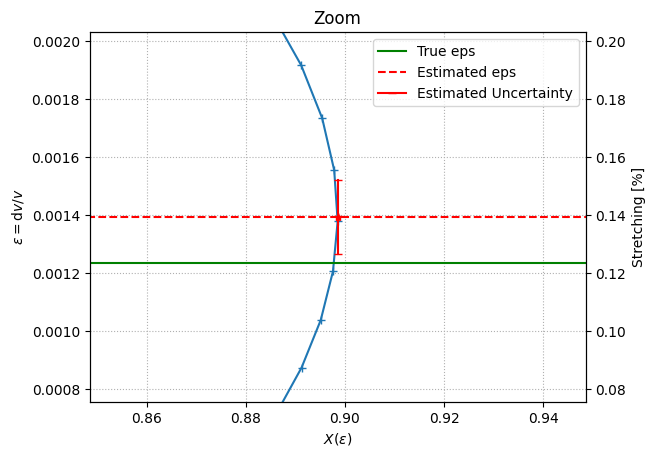

In [12]:
# ZOOM IN
ax = plt.subplot(111, xlabel=r"$ X(\epsilon) $", ylabel=r"$ \epsilon = \mathrm{d}v/v $", title='Zoom')

ax.plot(c, stretcher.eps, '+-')
ax.grid(True, linestyle=":")

ax.plot(ax1.get_xlim(), [eps_true, eps_true], 'g-', label="True eps")

ax.plot(c_max, eps_max, "r*")
ax.plot(ax1.get_xlim(), [eps_max, eps_max], 'r--', label="Estimated eps")

ax.plot([c_max, c_max], [eps_max-eps_unc, eps_max+eps_unc], "r_-", label="Estimated Uncertainty")

ax.set_xlim((c_max - 0.05, c_max + 0.05))
ax.set_ylim((eps_max - 5 * eps_unc, eps_max + 5 * eps_unc))
ax.legend();

bx = ax.twinx()
bx.set_ylim(np.asarray(ax.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');

## Case 2 : Find the stretching history in a b-scan using a single reference<a id="case2"></a>

### Step 1 : Generate a b-scan with varying stretching as a function of time<a id="case2step1"></a>

In [13]:
# Genereate a synthetic stretching history
n_traces = 256  # number of traces

eps_history = np.linspace(0., 0.002, n_traces)
eps_history += 0.0003 * np.sin(2. * np.pi * np.arange(n_traces) / 150)
x = (np.arange(n_traces)-n_traces//2) / 20.
eps_history += -0.0009 * np.exp(-x) * (x > 0)

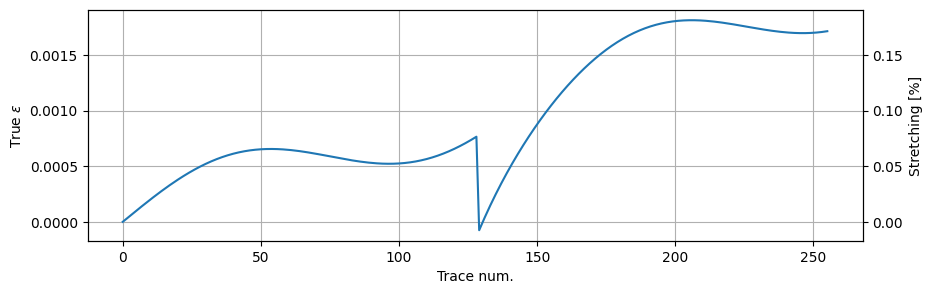

In [14]:
plt.figure(figsize=(10, 3))
ax = plt.subplot(111, ylabel='True $ \epsilon $', xlabel='Trace num.')
ax.plot(eps_history)
ax.grid(True)
bx = ax.twinx()
bx.set_ylim(np.asarray(ax.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');

In [15]:
# Build the synthetic bscan by stretching the reference, add noise
with Timer('Build the stretcher to generate the bscan'):
    stretcher0 = Stretcher(nt=nt, dt=dt, t0=t0, eps=eps_history, norm=False, interp_kind=interp_kind)

ascan = bandpass(np.random.randn(n_traces, nt)) * taper
with Timer('Generate the bscan'):
    bscan = stretcher0.stretch(ascan)

bscan += bandpass(np.random.randn(n_traces, nt) * noise_level)
bscan *= taper

# bscan[:n_traces//3] += bandpass(np.random.randn(n_traces//3,nt) * noise_level * 4.)

Timer[Build the stretcher to generate the bscan]: 1579.54 ms
Timer[Generate the bscan]: 679.18 ms


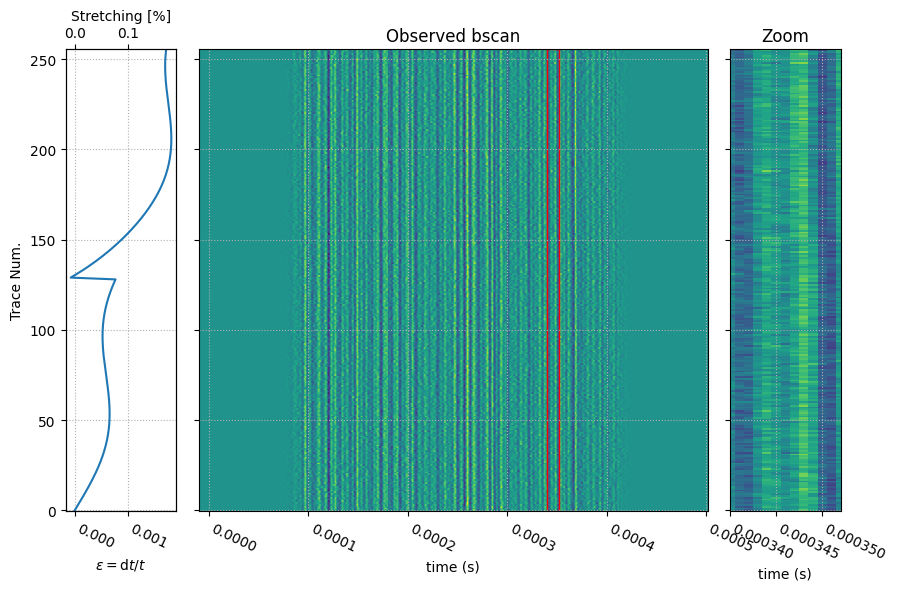

In [16]:
# Display
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 6)

ax1 = plt.subplot(gs[0, 0], xlabel=r"$ \epsilon = \mathrm{d}t/t $", ylabel="Trace Num.")
ax2 = plt.subplot(gs[0, 1:-1], sharey=ax1, xlabel="time (s)", title="Observed bscan")
ax3 = plt.subplot(gs[0, -1], sharey=ax1, xlabel="time (s)", title="Zoom")

ax1.plot(eps_history, np.arange(n_traces), '-')
ax2.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");

ax3.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");
xmin, xmax = tmin + 0.8 * (tmax - tmin), tmin + 0.84 * (tmax - tmin)
ax2.fill_betweenx(ax2.get_ylim(), [xmin, xmin], [xmax, xmax], color="none", edgecolor="r")
ax3.set_xlim(xmin, xmax)


for ax in [ax2, ax3]:
    plt.setp(ax.get_yticklabels(), visible=False)
    
for ax in [ax1, ax2, ax3]:
    plt.setp(ax.get_xticklabels(), ha="left", rotation=-25)
    ax.grid(True, linestyle=":")
bx = ax1.twiny()
bx.set_xlim(np.asarray(ax1.get_xlim())*100.)
bx.set_xlabel(r'Stretching [%]');

### Step 2 : Pre-compute the stretched versions of the reference.<a id="case2step2"></a>

In [17]:
# Choose a reference signal in the bscan (first trace)
i_reference = 0
y_reference = bscan[i_reference, :]   # so that the reference also includes noise
assert eps_history[i_reference] == 0.

In [18]:
# Build the stretching basis of the reference signal

# epsilon search grid
eps_search = polyspace(
    xmin=eps_search_min, 
    xmax=eps_search_max, 
    nx=n_eps, 
    pwr=eps_pw)

# for correlation this time (do not use stretcher0)
with Timer('Build the stretcher object'):
    stretcher = Stretcher(t0=t0, nt=nt, dt=dt, eps=eps_search, norm=True, interp_kind=interp_kind)  

with Timer('Compute the stretched reference basis'):
    y_reference_stretched = stretcher.stretch(y_reference)  # compute the stretching basis of the reference

Timer[Build the stretcher object]: 600.43 ms
Timer[Compute the stretched reference basis]: 8.44 ms


In [19]:
# Display (same as above)
if False:
    plt.figure(figsize=(10, 6))
    plt.gca().set_xlabel('time (s)')
    plt.gca().set_ylabel('$ \epsilon $')
    plt.pcolormesh(stretcher.t, stretcher.eps, y_reference_stretched, shading="auto");
    plt.gca().plot(eps_search * 0, eps_search, "k_"); # show the epsilon grid as ticks on yaxis

### Step 3 : Correlate all signals of the bscan with the reference<a id="case2step3"></a>

In [20]:
# Correlate all traces to the reference
with Timer(f'Correlate and find maxima in a bscan of {n_traces} traces with a single reference'):
    c = stretcher.corr(bscan, y_reference_stretched)
    eps_max_history, c_max_history = stretcher.corrmax(c)
    eps_unc_history = stretcher.stretching_uncertainty(
        cmax=c_max_history, fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax)


Timer[Correlate and find maxima in a bscan of 256 traces with a single reference]: 16.09 ms


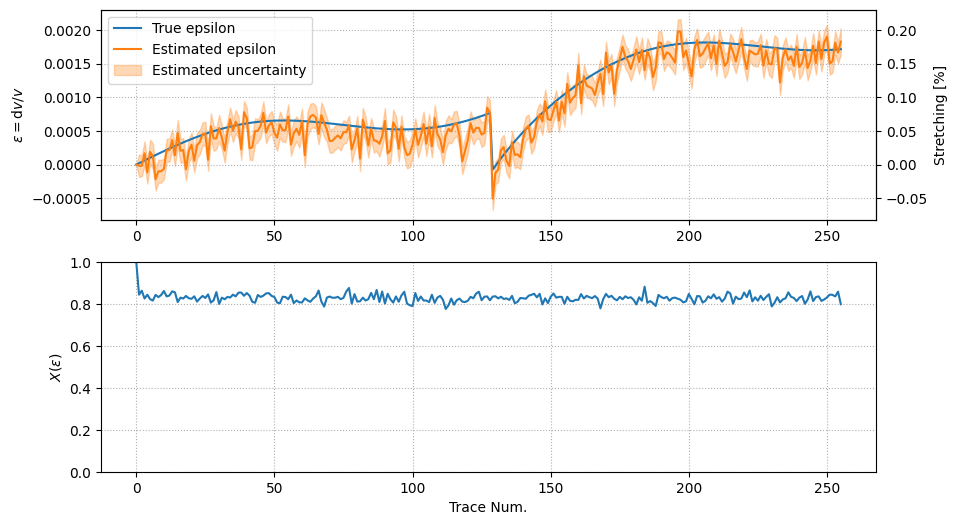

In [21]:
# Display
plt.figure(figsize=(10, 6))

ax1=plt.subplot(211, ylabel="$ \epsilon = \mathrm{d}v/v $")
ax1.plot(np.arange(n_traces), eps_history, label="True epsilon")
hdl, = ax1.plot(np.arange(n_traces), eps_max_history, label="Estimated epsilon")
ax1.fill_between(
    x=np.arange(n_traces), 
    y1=eps_max_history-eps_unc_history, 
    y2=eps_max_history+eps_unc_history,
    color=hdl.get_color(), alpha=0.3,
    label="Estimated uncertainty")   
ax1.legend()
ax1.grid(True, linestyle=":")

ax2 = plt.subplot(212, sharex=plt.gca(), ylabel="$ X(\epsilon) $", xlabel="Trace Num.")
ax2.plot(np.arange(n_traces), c_max_history);
ax2.set_ylim(0., 1.)
ax2.grid(True, linestyle=":")

bx = ax1.twinx()
bx.set_ylim(np.asarray(ax1.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');


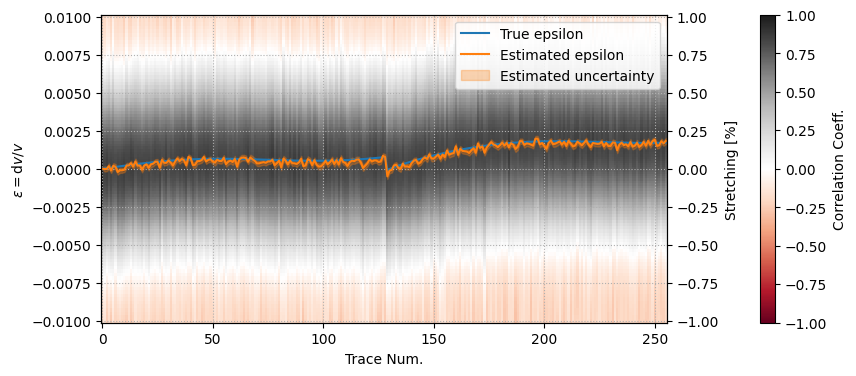

In [22]:
# Display the full correlation function to track possible cycle skip effects when the stretching is 
# very strong relative to the time period in the late coda part
plt.figure(figsize=(10, 4))

ax1 = plt.subplot(111, ylabel="$ \epsilon = \mathrm{d}v/v $", xlabel="Trace Num.")

coll = ax1.pcolormesh(
    np.arange(n_traces), stretcher.eps, c, shading="auto", 
    vmin=-1.0, vmax=1.0, 
    cmap=plt.get_cmap('RdGy'))
plt.colorbar(coll, pad=0.12, label="Correlation Coeff.")

ax1.plot(np.arange(n_traces), eps_history, label="True epsilon")

hdl, = ax1.plot(np.arange(n_traces), eps_max_history, label="Estimated epsilon")

ax1.fill_between(
    x=np.arange(n_traces), 
    y1=eps_max_history-eps_unc_history, 
    y2=eps_max_history+eps_unc_history,
    color=hdl.get_color(), alpha=0.3,
    label="Estimated uncertainty")   

ax1.legend()
ax1.grid(True, linestyle=":")
bx = ax1.twinx()
bx.set_ylim(np.asarray(ax1.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');


## Case 3 : Find the stretching history in a b-scan without any reference<a id="case3"></a>
(under development): The approach is similar to Brenguier et al., 2014 (supp. mat.) except that we consider that solving a least square inverse problem is not necessary to infer the stretching history from the cross-stretching matrix as the problem is well posed.

We note $ y_i(t) $  the signal measured at calendar time $ T_i $.  
The stretching correlation function is defined following Weaver et al., 2011 :

$$ 
\left\{ y_i, y_j \right\}(\varepsilon) = 
X_{ij}(\varepsilon) = 
\frac
    {\int y_i(t \times (1+\varepsilon)) . y_j(t) \, dt }
    {\sqrt{
        \int y_i^2(t) \, dt 
        \int y_j^2(t) \, dt }}
$$

The stretching coefficient matrix gives the best stretching coefficient for each pair of times $Ti,Tj$

$$
\varepsilon_{ij} = argmax[X_{ij}(\varepsilon)]
$$

The correlation coefficient matrix is the maximum of the normalized stretching correlation for each pair of times $Ti,Tj$

$$
C_{ij} = X_{ij}(\varepsilon_{ij})
$$

If the source is stable in time, 
the signals at calendar times $ T_i $ and $ T_j $ 
are two stretched version of the same reference $ u_0 $, thus  

$$
\left\{
\begin{aligned}
y_i(t) &= u_0(t \times (1 + \varepsilon^{true}(T_i))  \\
y_j(t) &= u_0(t \times (1 + \varepsilon^{true}(T_j)) \\
\end{aligned}
\right.
$$

Then, one can show that   

$$
X_{ij}(\varepsilon) \approx \left\{ u_0, u_0 \right\}\left(\varepsilon + \varepsilon^{true}(T_{i}) - \varepsilon^{true}(T_{j}) + \mathcal{O}(\varepsilon^{2})\right)
$$

As the auto-stretching-correlation of $u_0$ peaks at $\varepsilon=0$, then 

$$
\varepsilon_{ij} = argmax [X_{ij}] \approx \varepsilon^{true}(T_{j}) - \varepsilon^{true}(T_{i}) + \mathcal{O}(\varepsilon^{2})
$$

The zero-mean stretching history can be obtained by averaging vertically (or horizontally) the stretching matrix :  

$$ 
\varepsilon^{true}(T_{j}) - \left< \varepsilon^{true} \right> \approx \frac{1}{N} \sum_{i=0}^{N-1} \varepsilon_{ij} 
$$

One can improve this averaging by weighting the stretching measurements by the correlation coefficients (no Einstein summation)

$$ 
\varepsilon^{true}(T_{j}) - \left< \varepsilon^{true} \right> \approx \frac {\sum_{i=0}^{N-1} C_{ij}^\gamma \times \varepsilon_{ij} } {\sum_{i=0}^{N-1} C_{ij}^\gamma } 
$$

where $ \gamma $ is a power coefficient used to increase the weight of the best fitting pairs of correlation functions

### Compute the stretching and correlation matrices

In [23]:
with Timer('Correlate all pairs of traces in the bscan'):
    c_triu, e_triu = stretcher.corr_all_with_all(bscan)
    
# convert to square arrays
c2d = stretcher.triu2dense(c_triu, symetric=True, diag=1)
e2d = stretcher.triu2dense(e_triu, symetric=False, diag=0)

Timer[Correlate all pairs of traces in the bscan]: 4395.92 ms


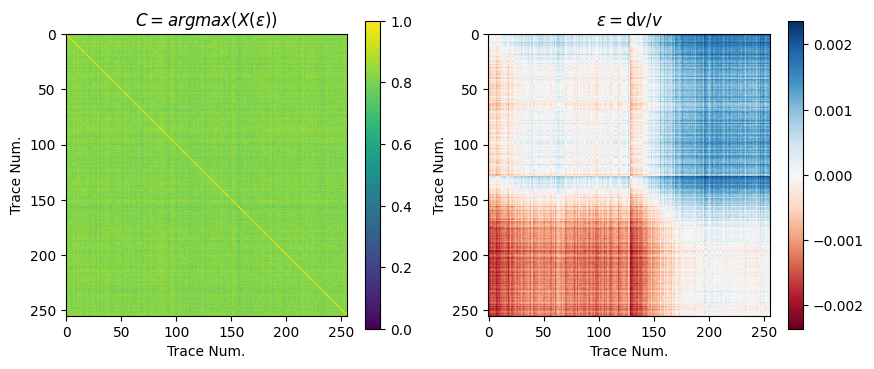

In [24]:
# Display
plt.figure(figsize=(10, 4))

plt.subplot(121, title="$ C=argmax ( X(\epsilon) ) $", xlabel="Trace Num.", ylabel="Trace Num.")
plt.colorbar(
    plt.imshow(c2d, 
               vmin=0., vmax=1.0, 
               cmap=plt.get_cmap('viridis')))

plt.subplot(122, title="$ \epsilon = \mathrm{d}v/v $", xlabel="Trace Num.", ylabel="Trace Num.")
plt.colorbar(
    plt.imshow(
        e2d, 
        vmin=-np.abs(e2d).max(),
        vmax=+np.abs(e2d).max(),
        cmap=plt.get_cmap('RdBu'))
    );

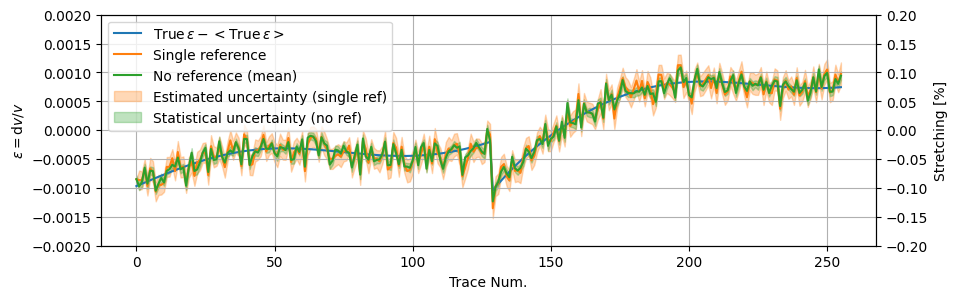

In [25]:
# recover the stretching history
eps_mean_history = (e2d - e2d.mean(axis=1)[:, np.newaxis]).mean(axis=0)
eps_std_history = np.std(e2d - e2d.mean(axis=1)[:, np.newaxis], axis=0)

plt.figure(figsize=(10, 3))
ax1 = plt.subplot(111, xlabel="Trace Num.", ylabel=r"$ \epsilon = \mathrm{d}v/v $")
ax1.plot(eps_history - eps_history.mean(), label=r"$ \mathrm{True}\,\epsilon -  < \mathrm{True}\,\epsilon > $")

# replot single reference version
hdl, = ax1.plot(eps_max_history - eps_max_history.mean(), label="Single reference")
ax1.fill_between(
    x=np.arange(len(eps_max_history)), 
    y1=eps_max_history- eps_max_history.mean()-eps_unc_history , 
    y2=eps_max_history- eps_max_history.mean()+eps_unc_history , 
    color=hdl.get_color(), alpha=0.3, label="Estimated uncertainty (single ref)")

# add results for this section
hdl, = ax1.plot(eps_mean_history, label="No reference (mean)")
#hdl, = plt.plot(emed, label="No reference (median)")
ax1.fill_between(
    x=np.arange(len(eps_mean_history)), 
    y1=eps_mean_history-eps_std_history, 
    y2=eps_mean_history+eps_std_history, 
    color=hdl.get_color(), 
    alpha=0.3, label="Statistical uncertainty (no ref)")

ax1.legend();
ax1.set_ylim(-0.002, 0.002)
ax1.grid(True);

bx = ax1.twinx()
bx.set_ylim(np.asarray(ax1.get_ylim())*100.)
bx.set_ylabel(r'Stretching [%]');

## Case 4 : Iterative approach :  Inverse stretching <a id=case4></a>

An attempt to simulate the case where the reference signal is difficult to choose (varying noise sources, huge stretching variations, ...)  
and where the matrix approach above is too expensive,  
- We first evaluate the reference signal by taking the average of the bscan   
- The stretching history is estimated as usual, by correlation with the reference
- Then the bscan is corrected from the estimated stretching history (i.e. de-stretched) and averaged again to refine the estimate of the reference. The process can be iterated until the energy of the reference converges.


In [26]:
# Genereate a synthetic stretching history
n_traces = 1024  # number of traces

eps_history = np.linspace(0., 0.002, n_traces)
eps_history += 0.0003 * np.sin(2. * np.pi * np.arange(n_traces) / 150)
x = (np.arange(n_traces)-n_traces*2//3) / 20.
eps_history += -0.002 * np.exp(-x) * (x > 0)

eps_history *= 20  # simulate huge stretching rates

In [27]:
# Build the synthetic bscan by stretching the reference, add noise
stretcher0 = Stretcher(nt=nt, dt=dt, t0=t0, eps=eps_history, norm=False, interp_kind=interp_kind)

ascan = bandpass(np.random.randn(nt)) * taper
bscan = stretcher0.stretch(ascan)

bscan += bandpass(np.random.randn(n_traces, nt) * noise_level)
bscan[:n_traces//3] += bandpass(np.random.randn(n_traces//3,nt) * noise_level * 4.)
bscan *= taper

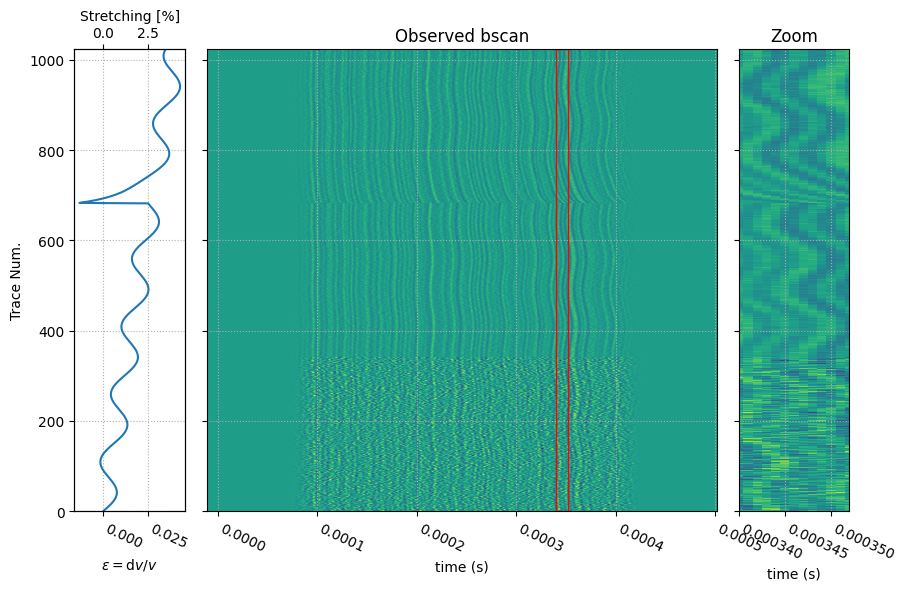

In [28]:
# Display
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 6)

ax1 = plt.subplot(gs[0, 0], xlabel=r"$ \epsilon = \mathrm{d}v/v $", ylabel="Trace Num.")
ax2 = plt.subplot(gs[0, 1:-1], sharey=ax1, xlabel="time (s)", title="Observed bscan")
ax3 = plt.subplot(gs[0, -1], sharey=ax1, xlabel="time (s)", title="Zoom")

ax1.plot(eps_history, np.arange(n_traces), '-')
ax2.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");

ax3.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");
xmin, xmax = tmin + 0.8 * (tmax - tmin), tmin + 0.84 * (tmax - tmin)
ax2.fill_betweenx(ax2.get_ylim(), [xmin, xmin], [xmax, xmax], color="none", edgecolor="r")
ax3.set_xlim(xmin, xmax)

for ax in [ax2, ax3]:
    plt.setp(ax.get_yticklabels(), visible=False)
    
for ax in [ax1, ax2, ax3]:
    plt.setp(ax.get_xticklabels(), ha="left", rotation=-25)
    ax.grid(True, linestyle=":")
bx = ax1.twiny()
bx.set_xlim(np.asarray(ax1.get_xlim())*100.)
bx.set_xlabel(r'Stretching [%]');

In [29]:
# Build the stretching basis of the reference signal
eps_search = polyspace(eps_search_min * 10, eps_search_max * 10, n_eps * 4, eps_pw)
stretcher = Stretcher(nt=nt, dt=dt, t0=t0, eps=eps_search, norm=True, interp_kind=interp_kind)

In [30]:
# Take the average bscan as reference to start the process
y_reference = bscan.mean(axis=0)  # the reference might not be optimal if some traces are bad

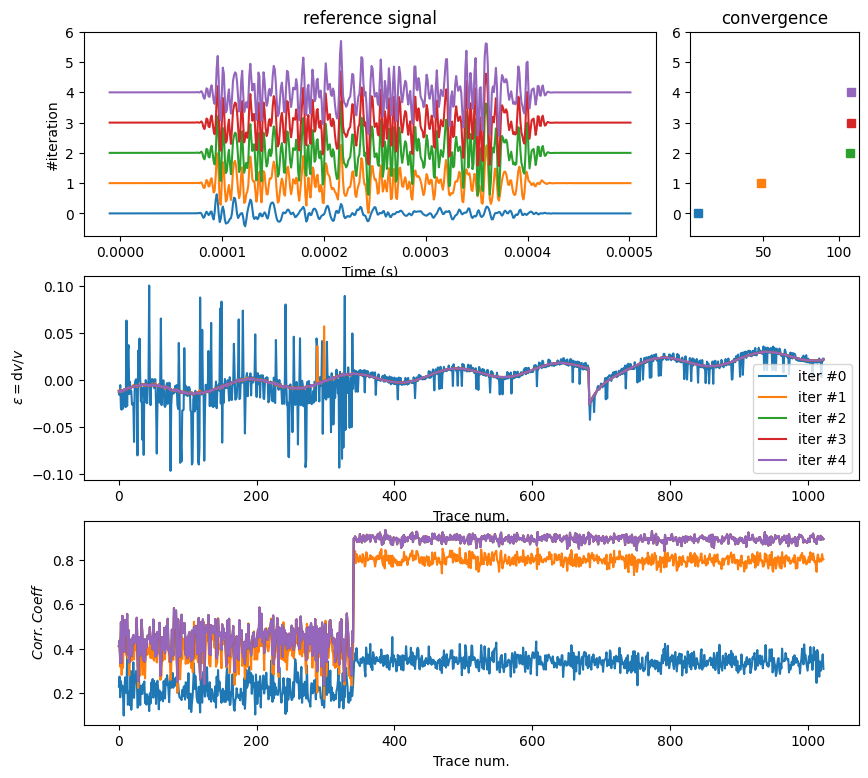

In [31]:
from coodddaaaa.stretching import InverseStretcher

fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(3, 4)
ax1 = fig.add_subplot(gs[0, :-1], ylabel="#iteration", xlabel="Time (s)", title="reference signal")
bx1 = fig.add_subplot(gs[0, -1], sharey=ax1, title="convergence")
ax2 = fig.add_subplot(gs[1, :], ylabel=r"$ \epsilon = \mathrm{d}v/v $", xlabel="Trace num.")
#ax3 = ax2.twinx(); ax3.set_ylabel("Corr. Coeff")
ax3 = fig.add_subplot(gs[2, :], ylabel=r"$ Corr. Coeff $", xlabel="Trace num.", sharex=ax2)

for _ in range(5):
    hdl, = ax1.plot(time_array, y_reference + _, label=f"iter #{_:1d}")
    bx1.plot((y_reference ** 2.0).sum(), _, "s", color=hdl.get_color())
    
    # compute the stretching basis of the current version of the reference
    y_reference_stretched = stretcher.stretch(y_reference)  
    
    # correlate the bscan with it
    c = stretcher.corr(bscan, y_reference_stretched)
    eps_max_history, c_max_history = stretcher.corrmax(c)
    
    ax2.plot(eps_max_history, label=f"iter #{_:1d}", color=hdl.get_color())
    ax3.plot(c_max_history, "-", label=f"iter #{_:1d}", color=hdl.get_color())
    
    # cancel the observed stretching history 
    # the inverse stretched must be reset at each iteration because 
    # it is only valid for a given stretching history
    inverse_stretcher = InverseStretcher(
        nt=nt, dt=dt, t0=t0,
        eps_history=eps_max_history,
        interp_kind="linear",  # only linear here !!
        ) 
    bscan_corrected = inverse_stretcher(bscan) 
    
    # average the un-stretched bscan to get the new estimate of the reference
    if False:
        # the new reference is the simple average of the unstretched bscan
        y_reference = bscan_corrected.mean(axis=0)
    else:
        # the new reference is the weighted average of the unstretched bscan, using the stretching correl. coeff.
        y_reference = (c_max_history[:, np.newaxis] * bscan_corrected).sum(axis=0) / c_max_history.sum()
    
    # TODO : weight the average by the correlation coeff of each trace
ax2.legend(loc="best")


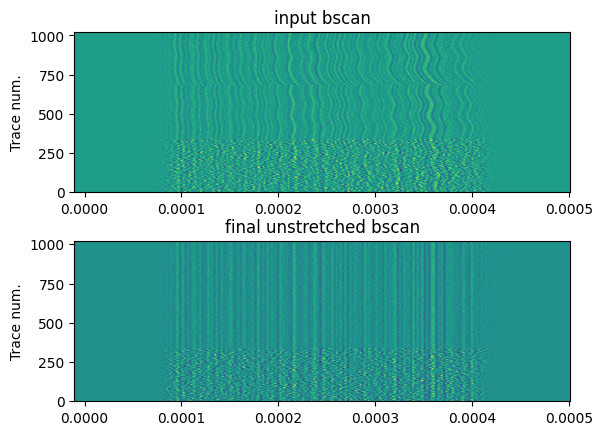

In [32]:
# The corrected bscan should be aligned correctly    
plt.gcf().subplots_adjust(hspace=0.3)
plt.subplot(211, title="input bscan", ylabel="Trace num.")
plt.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto")

plt.subplot(212, sharex=plt.gca(), sharey=plt.gca(), title="final unstretched bscan", ylabel="Trace num.")
plt.pcolormesh(stretcher.t, np.arange(n_traces), bscan_corrected, shading="auto"); 